In [4]:

using PKAssetPrices.Dynamic: DynamicModel, DiscreteTime, DynamicParametrization, solve_model, @model
using PKAssetPrices
using CairoMakie

In [ ]:
sol_baseline =  solve_model(Dynamic.DynQconAPLevelChange2)

PKAssetPrices.Dynamic.DynamicSolution{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicParametrization{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicModel{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80"}(DiscreteTime([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]), PKAssetPrices.Dynamic.DynVar[PKAssetPrices.Dynamic.DynVar(:Y, "Output"), PKAssetPrices.Dynamic.DynVar(:ND, "Non debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:D, "debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:i, "policy rate"), PKAssetPrices.Dynamic.DynVar(:r, "interest rate"), PKAssetPrices.Dynamic.DynVar(:P, "price level"), PKAssetPrices.Dynamic.DynVar(:dL, "change in loans"), PKAssetPrices.Dynamic.DynVar(:dM, "change in money"), PKAssetPrices.Dynamic.DynVar(:dR, "change in reserves"), PKAssetPrices.Dynamic.DynV

# Asset market

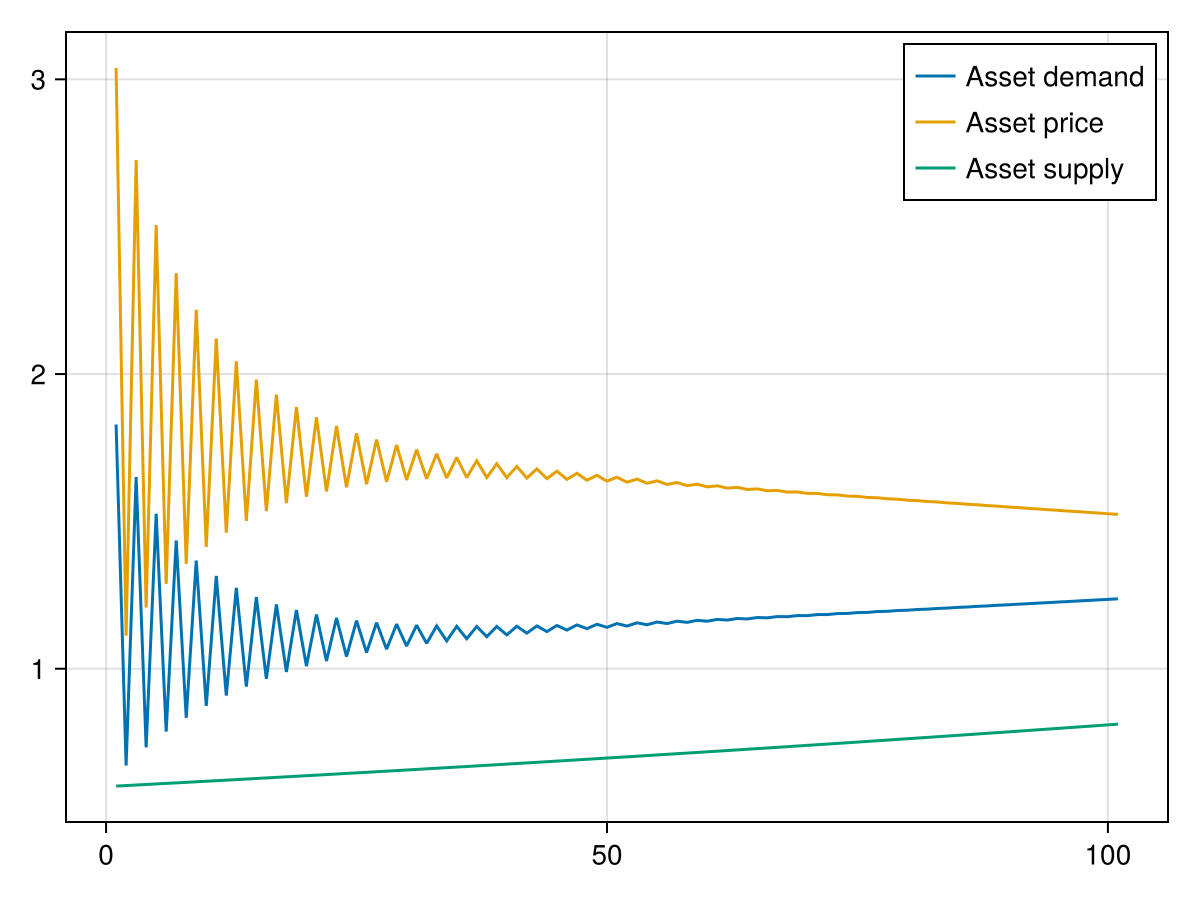

In [7]:

f = Figure()
ax = Axis(f[1,1])
lines!(ax,sol_baseline.paths[:AD], label = "Asset demand")
lines!(ax,sol_baseline.paths[:AP], label = "Asset price")
lines!(ax,sol_baseline.paths[:AS], label = "Asset supply")
axislegend(ax)
f

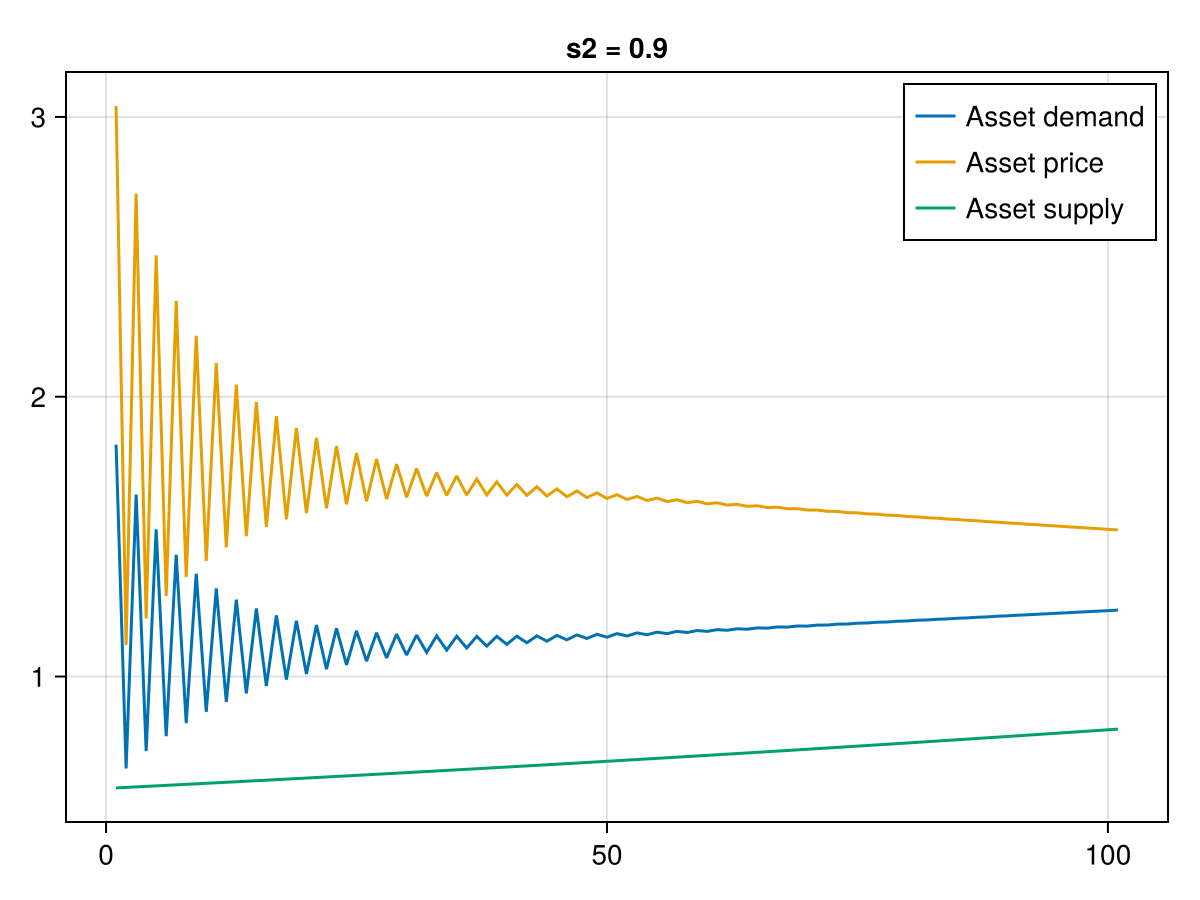

In [18]:
s2_values = range(0.1, 0.9, length = 100)
xs = 1:length(sol_baseline.paths[:AD])

ys_ad = Observable(sol_baseline.paths[:AD])
ys_ap = Observable(sol_baseline.paths[:AP])
ys_as = Observable(sol_baseline.paths[:AS])

f = Figure()
ax = Axis(f[1, 1])
lines!(ax, xs, ys_ad, label = "Asset demand")
lines!(ax, xs, ys_ap, label = "Asset price")
lines!(ax, xs, ys_as, label = "Asset supply")
axislegend(ax)

record(f, "../plots/asset_market_s2_animation.gif", 1:length(s2_values)) do i
    scen = Dynamic.@scenario Dynamic.DynQconAPLevelChange2 begin
         s2 = s2_values[i]
     end
    sol = solve_model(scen)
    ys_ad[] = sol.paths[:AD]
    ys_ap[] = sol.paths[:AP]
    ys_as[] = sol.paths[:AS]
    ax.title = "s2 = $(round(s2_values[i], digits=2))"
end

f

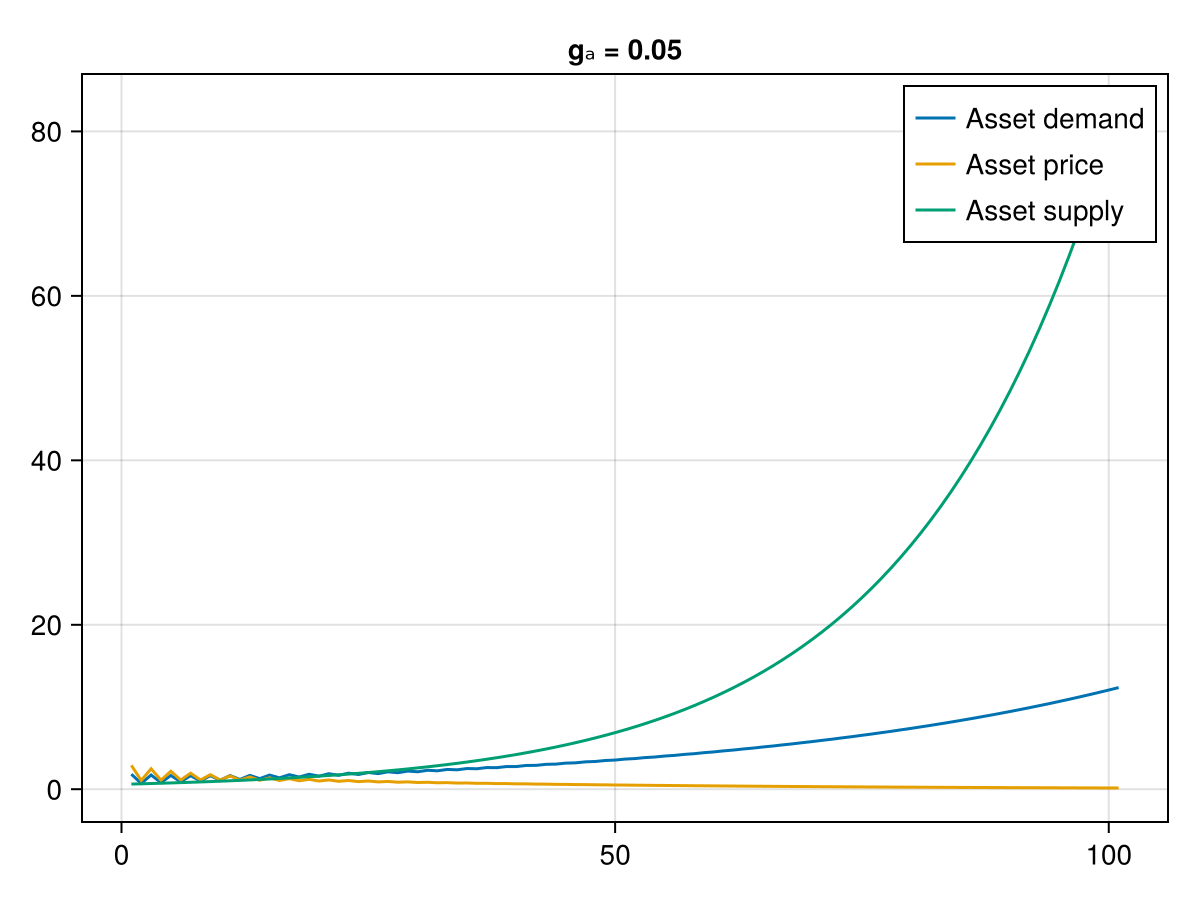

In [17]:
gₐ_values = range(0.0001, 0.05, length = 100)
xs = 1:length(sol_baseline.paths[:AD])

ys_ad = Observable(sol_baseline.paths[:AD])
ys_ap = Observable(sol_baseline.paths[:AP])
ys_as = Observable(sol_baseline.paths[:AS])

f = Figure()
ax = Axis(f[1, 1])
lines!(ax, xs, ys_ad, label = "Asset demand")
lines!(ax, xs, ys_ap, label = "Asset price")
lines!(ax, xs, ys_as, label = "Asset supply")
axislegend(ax)

record(f, "../plots/asset_market_gₐ_animation.gif", 1:length(gₐ_values)) do i
    scen = Dynamic.@scenario Dynamic.DynQconAPLevelChange2 begin
         gₐ = gₐ_values[i]
     end
    sol = solve_model(scen)
    ys_ad[] = sol.paths[:AD]
    ys_ap[] = sol.paths[:AP]
    ys_as[] = sol.paths[:AS]
    ax.title = "gₐ = $(round(gₐ_values[i], digits=4))"
end

f

# Real economy


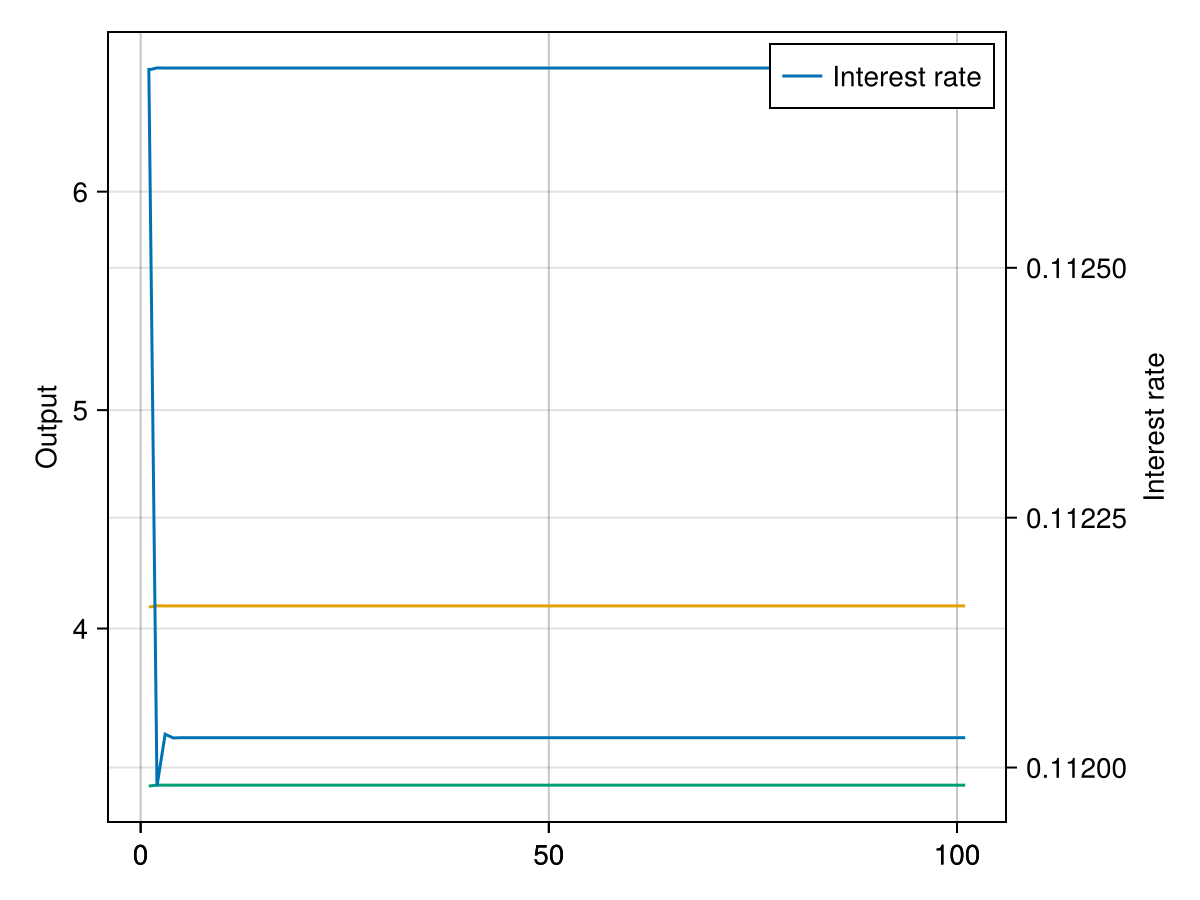

In [ ]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Output")

lines!(ax,sol_baseline.paths[:Y], label = "GDP")
lines!(ax,sol_baseline.paths[:D], label = "Debt financed demand")
lines!(ax,sol_baseline.paths[:ND], label = "Non-debt financed deman")
f

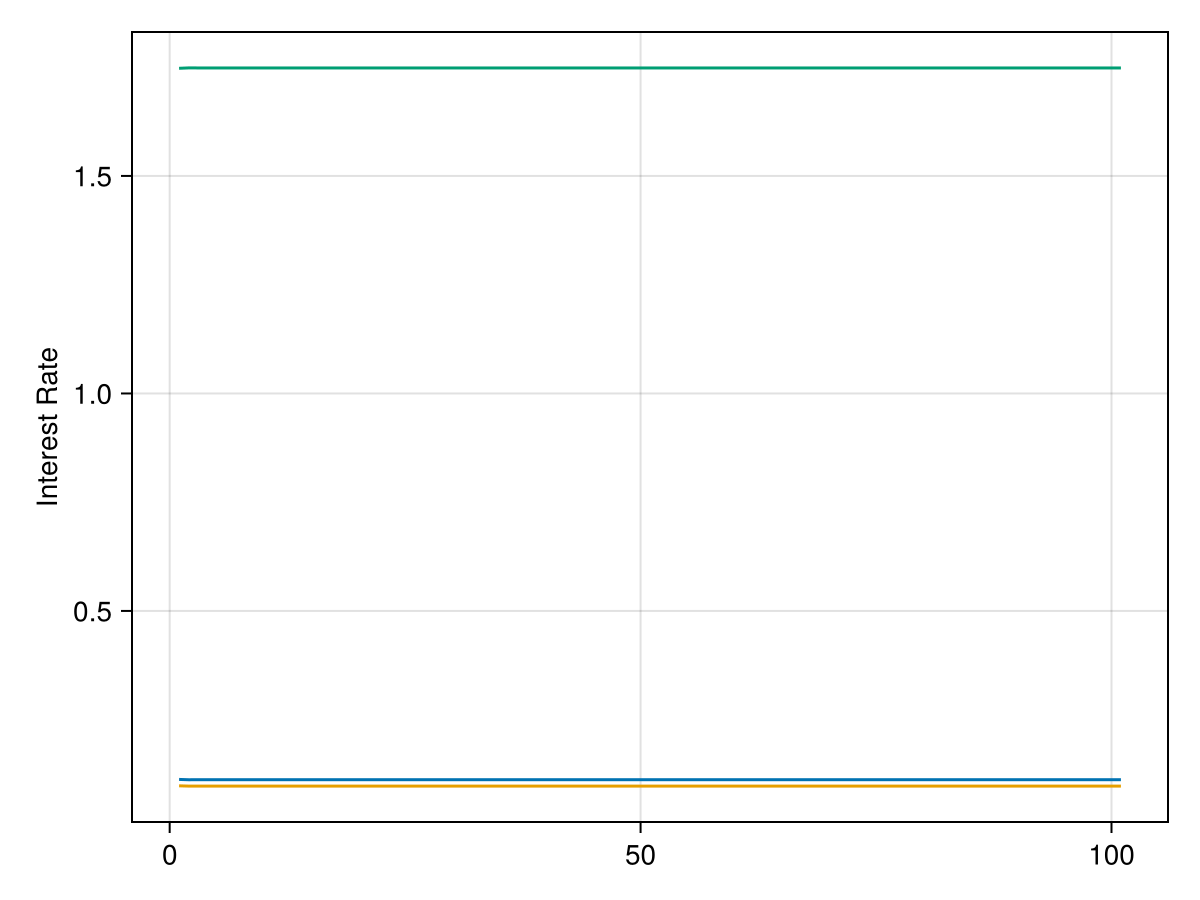

In [ ]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Interest Rate")

lines!(ax,sol_baseline.paths[:r], label = "Interest rate")
lines!(ax,sol_baseline.paths[:i], label = "Policy rate")
lines!(ax,sol_baseline.paths[:P], label = "Prices")
f